In [1]:
import pandas as pd

In [32]:
# ============================================
# IMPORTS
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import StandardScaler

# ML models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All libraries imported successfully.")

All libraries imported successfully.


In [3]:

file_path = r"C:\Users\minsa_\OneDrive\Documents\Disease_Binary_Model.xlsx"

excel_file = pd.ExcelFile(file_path)

excel_file.sheet_names

['Sheet1']

In [4]:
df = pd.read_excel(
    file_path,
    sheet_name="Sheet1"
)

df.head()

,Tissue_ID,Eye,Image_ID,Disease_Label,Disease_Severity,ECD_CD_cells_per_mm2,CV,HEX_percent,SD,Disease_Present,Biomarkers_Complete
0,NEB-2020-09-12654 R,Right,NEB-2020-09-12654 R_SP,Normal,NaN,2132.0,33.0,58.0,153.0,0,1
1,NEB-2020-09-12655 L,Left,NEB-2020-09-12655 L_SP,Folds,Moderate,2212.0,33.0,47.0,147.0,1,1
2,NEB-2020-09-12656 R,Right,NEB-2020-09-12656 R_SP,Normal,NaN,2538.0,35.0,53.0,137.0,0,1
3,NEB-2020-09-12657 L,Left,NEB-2020-09-12657 L_SP,Folds,Mild,2584.0,29.0,69.0,112.0,1,1
4,NEB-2020-09-12658 R,Right,NEB-2020-09-12658 R_SP,Normal,NaN,3115.0,38.0,49.0,122.0,0,1


In [5]:
df["Disease_Label"].value_counts()

Disease_Label
Normal                                                                   504
Folds                                                                    324
FECD; Polymorphism and pleomorphism; Low cell density                     88
Guttata                                                                   53
Guttata; Folds                                                            28
FECD; Polymorphism and pleomorphism; Low cell density; Folds              20
FECD; Polymorphism and pleomorphism; Low cell density; Guttata             8
Polymorphism and pleomorphism                                              5
Poor cornea                                                                5
Folds; Guttata                                                             3
FECD; Polymorphism and pleomorphism; Low cell density; Guttata; Folds      3
Guttata; FECD; Polymorphism and pleomorphism; Low cell density             2
FECD; Polymorphism and pleomorphism                           

In [6]:
disease_counts = (
    df["Disease_Label"]
    .value_counts()
    .to_frame("Count")
)

disease_counts

,Count
Disease_Label,
Normal,504
Folds,324
FECD; Polymorphism and pleomorphism; Low cell density,88
Guttata,53
Guttata; Folds,28
FECD; Polymorphism and pleomorphism; Low cell density; Folds,20
FECD; Polymorphism and pleomorphism; Low cell density; Guttata,8
Polymorphism and pleomorphism,5
Poor cornea,5


In [7]:
df["Disease_Label"].unique()

<StringArray>
[                                                               'Normal',
                                                                 'Folds',
                 'FECD; Polymorphism and pleomorphism; Low cell density',
        'FECD; Polymorphism and pleomorphism; Low cell density; Guttata',
                                                        'Guttata; Folds',
                                                        'Folds; Guttata',
                                                               'Guttata',
          'FECD; Polymorphism and pleomorphism; Low cell density; Folds',
          'Folds; FECD; Polymorphism and pleomorphism; Low cell density',
 'FECD; Polymorphism and pleomorphism; Low cell density; Guttata; Folds',
                                                                  'FECD',
        'Guttata; FECD; Polymorphism and pleomorphism; Low cell density',
                                         'Polymorphism and pleomorphism',
                        

In [8]:
multi_label = df[
    df["Disease_Label"].str.contains(";", na=False)
]

multi_label[
    ["Image_ID", "Disease_Label"]
].head(20)

,Image_ID,Disease_Label
19,NEB-2020-09-12673 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
24,NEB-2020-09-12678 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
27,NEB-2020-09-12681 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
54,NEB-2020-10-12708 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
55,NEB-2020-10-12709 R_SP,FECD; Polymorphism and pleomorphism; Low cell ...
56,NEB-2020-10-12710 L_SP,Guttata; Folds
58,NEB-2020-10-12712 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
59,NEB-2020-10-12713 R_SP,FECD; Polymorphism and pleomorphism; Low cell ...
78,NEB-2020-10-12734 L_SP,FECD; Polymorphism and pleomorphism; Low cell ...
79,NEB-2020-10-12735 R_SP,Folds; Guttata


In [9]:
print("Total records:", len(df))
print("Multi-label records:", len(multi_label))
print(
    "Multi-label percentage:",
    round(len(multi_label) / len(df) * 100, 2),
    "%"
)

Total records: 1054
Multi-label records: 159
Multi-label percentage: 15.09 %


In [10]:
diseases = [
    "FECD",
    "Guttata",
    "Folds",
    "Polymorphism and pleomorphism",
    "Low cell density",
    "Poor cornea"
]

for disease in diseases:
    count = df["Disease_Label"].str.contains(
        disease,
        case=False,
        na=False
    ).sum()
    
    print(f"{disease}: {count}")

FECD: 127
Guttata: 100
Folds: 380
Polymorphism and pleomorphism: 132
Low cell density: 126
Poor cornea: 5


In [11]:
df["Disease_Label"].eq("Normal").sum()

np.int64(504)

In [12]:
df["FECD"] = df["Disease_Label"].str.contains(
    "FECD",
    case=False,
    na=False
).astype(int)

df["Guttata"] = df["Disease_Label"].str.contains(
    "Guttata",
    case=False,
    na=False
).astype(int)

df["Folds"] = df["Disease_Label"].str.contains(
    "Folds",
    case=False,
    na=False
).astype(int)

df["Polymorphism_Pleomorphism"] = df["Disease_Label"].str.contains(
    "Polymorphism and pleomorphism",
    case=False,
    na=False
).astype(int)

df["Low_Cell_Density"] = df["Disease_Label"].str.contains(
    "Low cell density",
    case=False,
    na=False
).astype(int)

In [13]:
disease_columns = [
    "FECD",
    "Guttata",
    "Folds",
    "Polymorphism_Pleomorphism",
    "Low_Cell_Density"
]

df[disease_columns].sum()

FECD                         127
Guttata                      100
Folds                        380
Polymorphism_Pleomorphism    132
Low_Cell_Density             126
dtype: int64

In [14]:
df[
    [
        "Disease_Label",
        "FECD",
        "Guttata",
        "Folds",
        "Polymorphism_Pleomorphism",
        "Low_Cell_Density"
    ]
].head(20)

,Disease_Label,FECD,Guttata,Folds,Polymorphism_Pleomorphism,Low_Cell_Density
0,Normal,0,0,0,0,0
1,Folds,0,0,1,0,0
2,Normal,0,0,0,0,0
3,Folds,0,0,1,0,0
4,Normal,0,0,0,0,0
5,Folds,0,0,1,0,0
6,Folds,0,0,1,0,0
7,Normal,0,0,0,0,0
8,Folds,0,0,1,0,0
9,Normal,0,0,0,0,0


In [15]:
overlap = df[disease_columns].T.dot(df[disease_columns])

overlap

,FECD,Guttata,Folds,Polymorphism_Pleomorphism,Low_Cell_Density
FECD,127,14,24,126,123
Guttata,14,100,35,15,14
Folds,24,35,380,25,24
Polymorphism_Pleomorphism,126,15,25,132,123
Low_Cell_Density,123,14,24,123,126


In [16]:
df[disease_columns].sum(axis=1).value_counts().sort_index()

0    510
1    385
2     34
3     91
4     31
5      3
Name: count, dtype: int64

In [17]:
df[disease_columns].sum(axis=1).value_counts().sort_index().to_frame(
    "Number_of_Diseases"
)

,Number_of_Diseases
0,510
1,385
2,34
3,91
4,31
5,3


In [18]:
disease_count_distribution = (
    df[disease_columns]
    .sum(axis=1)
    .value_counts()
    .sort_index()
    .rename_axis("Number_of_Diseases")
    .to_frame("Number_of_Records")
)

disease_count_distribution

,Number_of_Records
Number_of_Diseases,
0,510
1,385
2,34
3,91
4,31
5,3


In [19]:
df[disease_columns].value_counts().head(20)

FECD  Guttata  Folds  Polymorphism_Pleomorphism  Low_Cell_Density
0     0        0      0                          0                   510
               1      0                          0                   324
1     0        0      1                          1                    89
0     1        0      0                          0                    53
               1      0                          0                    31
1     0        1      1                          1                    21
      1        0      1                          1                    10
0     0        0      1                          0                     5
1     1        1      1                          1                     3
      0        0      1                          0                     2
0     0        0      0                          1                     2
1     0        0      0                          0                     1
      1        0      1                          0        

In [20]:
df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "FECD"
    ]
].isnull().sum()

ECD_CD_cells_per_mm2    51
CV                      51
HEX_percent             51
FECD                     0
dtype: int64

In [21]:
print("Total FECD:", df["FECD"].sum())
print(
    "FECD with missing biomarkers:",
    df.loc[df["FECD"] == 1, [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]].isnull().any(axis=1).sum()
)

Total FECD: 127
FECD with missing biomarkers: 3


In [22]:
fecd_df = df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "FECD"
    ]
].dropna().copy()

print("FECD dataset size:", len(fecd_df))
print("\nFECD classes:")
print(fecd_df["FECD"].value_counts())

FECD dataset size: 1003

FECD classes:
FECD
0    879
1    124
Name: count, dtype: int64


In [23]:
X = fecd_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = fecd_df["FECD"]

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
FECD
0    703
1     99
Name: count, dtype: int64

Testing classes:
FECD
0    176
1     25
Name: count, dtype: int64


In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [30]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

fecd_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

fecd_logistic.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [33]:
fecd_pred = fecd_logistic.predict(X_test_scaled)

fecd_prob = fecd_logistic.predict_proba(
    X_test_scaled
)[:, 1]

print("FECD Logistic Regression")
print("------------------------")

print(
    f"Accuracy : {accuracy_score(y_test, fecd_pred):.4f}"
)

print(
    f"Precision: {precision_score(y_test, fecd_pred):.4f}"
)

print(
    f"Recall   : {recall_score(y_test, fecd_pred):.4f}"
)

print(
    f"F1 Score : {f1_score(y_test, fecd_pred):.4f}"
)

print(
    f"ROC-AUC  : {roc_auc_score(y_test, fecd_prob):.4f}"
)

FECD Logistic Regression
------------------------
Accuracy : 0.9552
Precision: 0.7353
Recall   : 1.0000
F1 Score : 0.8475
ROC-AUC  : 0.9675


In [34]:
print(
    classification_report(
        y_test,
        fecd_pred,
        target_names=["No FECD", "FECD"]
    )
)

              precision    recall  f1-score   support

     No FECD       1.00      0.95      0.97       176
        FECD       0.74      1.00      0.85        25

    accuracy                           0.96       201
   macro avg       0.87      0.97      0.91       201
weighted avg       0.97      0.96      0.96       201



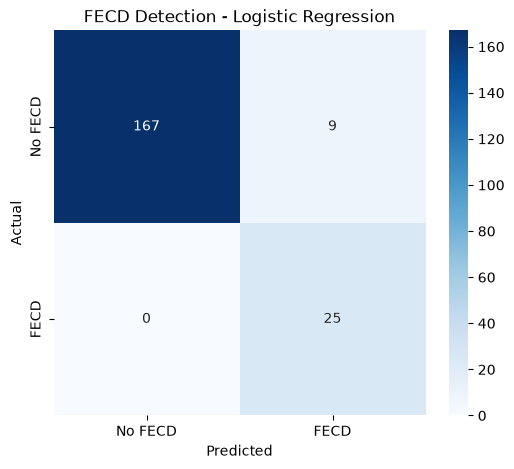

In [35]:
cm = confusion_matrix(y_test, fecd_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No FECD", "FECD"],
    yticklabels=["No FECD", "FECD"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FECD Detection - Logistic Regression")

plt.show()

In [36]:
rf_fecd = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_fecd.fit(X_train, y_train)

rf_fecd_pred = rf_fecd.predict(X_test)
rf_fecd_prob = rf_fecd.predict_proba(X_test)[:, 1]

In [37]:
rf_accuracy = accuracy_score(y_test, rf_fecd_pred)
rf_precision = precision_score(y_test, rf_fecd_pred)
rf_recall = recall_score(y_test, rf_fecd_pred)
rf_f1 = f1_score(y_test, rf_fecd_pred)
rf_roc_auc = roc_auc_score(y_test, rf_fecd_prob)

print("FECD Random Forest")
print("------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

FECD Random Forest
------------------
Accuracy : 0.9552
Precision: 0.7353
Recall   : 1.0000
F1 Score : 0.8475
ROC-AUC  : 0.9834


In [38]:
print(
    classification_report(
        y_test,
        rf_fecd_pred,
        target_names=["No FECD", "FECD"]
    )
)

              precision    recall  f1-score   support

     No FECD       1.00      0.95      0.97       176
        FECD       0.74      1.00      0.85        25

    accuracy                           0.96       201
   macro avg       0.87      0.97      0.91       201
weighted avg       0.97      0.96      0.96       201



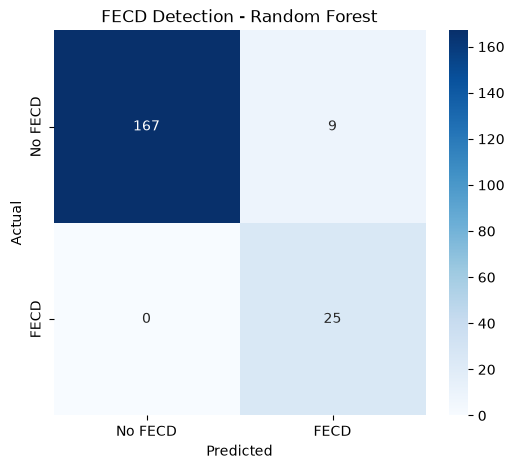

In [39]:
cm_rf = confusion_matrix(y_test, rf_fecd_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No FECD", "FECD"],
    yticklabels=["No FECD", "FECD"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FECD Detection - Random Forest")
plt.show()

In [40]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_fecd.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.913753
1,CV,0.045710
2,HEX_percent,0.040537


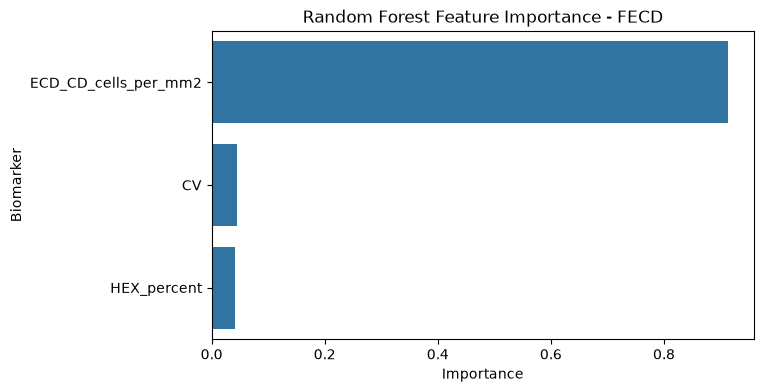

In [41]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance - FECD")
plt.xlabel("Importance")
plt.ylabel("Biomarker")

plt.show()

In [42]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, fecd_pred),
        accuracy_score(y_test, rf_fecd_pred)
    ],
    "Precision": [
        precision_score(y_test, fecd_pred),
        precision_score(y_test, rf_fecd_pred)
    ],
    "Recall": [
        recall_score(y_test, fecd_pred),
        recall_score(y_test, rf_fecd_pred)
    ],
    "F1 Score": [
        f1_score(y_test, fecd_pred),
        f1_score(y_test, rf_fecd_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, fecd_prob),
        roc_auc_score(y_test, rf_fecd_prob)
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9552,0.7353,1.0,0.8475,0.9675
1,Random Forest,0.9552,0.7353,1.0,0.8475,0.9834


In [43]:
guttata_df = df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Guttata"
    ]
].dropna().copy()

print("Guttata dataset size:", len(guttata_df))
print("\nGuttata classes:")
print(guttata_df["Guttata"].value_counts())

Guttata dataset size: 1003

Guttata classes:
Guttata
0    904
1     99
Name: count, dtype: int64


In [44]:
X = guttata_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = guttata_df["Guttata"]

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
Guttata
0    723
1     79
Name: count, dtype: int64

Testing classes:
Guttata
0    181
1     20
Name: count, dtype: int64


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

guttata_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

guttata_logistic.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [47]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

guttata_pred = guttata_logistic.predict(X_test_scaled)

guttata_prob = guttata_logistic.predict_proba(
    X_test_scaled
)[:, 1]

print("Guttata Logistic Regression")
print("---------------------------")

print(f"Accuracy : {accuracy_score(y_test, guttata_pred):.4f}")
print(f"Precision: {precision_score(y_test, guttata_pred):.4f}")
print(f"Recall   : {recall_score(y_test, guttata_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, guttata_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, guttata_prob):.4f}")

Guttata Logistic Regression
---------------------------
Accuracy : 0.5224
Precision: 0.1042
Recall   : 0.5000
F1 Score : 0.1724
ROC-AUC  : 0.4942


In [48]:
from sklearn.ensemble import RandomForestClassifier

rf_guttata = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_guttata.fit(X_train, y_train)

rf_guttata_pred = rf_guttata.predict(X_test)
rf_guttata_prob = rf_guttata.predict_proba(X_test)[:, 1]

In [49]:
rf_guttata_accuracy = accuracy_score(y_test, rf_guttata_pred)
rf_guttata_precision = precision_score(y_test, rf_guttata_pred)
rf_guttata_recall = recall_score(y_test, rf_guttata_pred)
rf_guttata_f1 = f1_score(y_test, rf_guttata_pred)
rf_guttata_roc = roc_auc_score(y_test, rf_guttata_prob)

print("Guttata Random Forest")
print("--------------------")
print(f"Accuracy : {rf_guttata_accuracy:.4f}")
print(f"Precision: {rf_guttata_precision:.4f}")
print(f"Recall   : {rf_guttata_recall:.4f}")
print(f"F1 Score : {rf_guttata_f1:.4f}")
print(f"ROC-AUC  : {rf_guttata_roc:.4f}")

Guttata Random Forest
--------------------
Accuracy : 0.8209
Precision: 0.1364
Recall   : 0.1500
F1 Score : 0.1429
ROC-AUC  : 0.5729


In [50]:
feature_importance_guttata = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_guttata.feature_importances_
})

feature_importance_guttata = feature_importance_guttata.sort_values(
    "Importance",
    ascending=False
)

feature_importance_guttata

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.454948
2,HEX_percent,0.308359
1,CV,0.236693


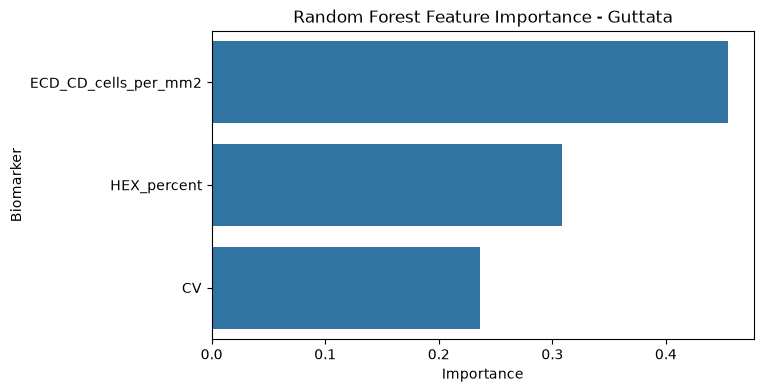

In [51]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=feature_importance_guttata,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance - Guttata")
plt.xlabel("Importance")
plt.ylabel("Biomarker")

plt.show()

In [52]:
folds_df = df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Folds"
    ]
].dropna().copy()

print("Folds dataset size:", len(folds_df))
print("\nFolds classes:")
print(folds_df["Folds"].value_counts())

Folds dataset size: 1003

Folds classes:
Folds
0    628
1    375
Name: count, dtype: int64


In [53]:
X = folds_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = folds_df["Folds"]

In [54]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
Folds
0    502
1    300
Name: count, dtype: int64

Testing classes:
Folds
0    126
1     75
Name: count, dtype: int64


In [55]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

folds_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

folds_logistic.fit(
    X_train_scaled,
    y_train
)

folds_pred = folds_logistic.predict(X_test_scaled)
folds_prob = folds_logistic.predict_proba(X_test_scaled)[:, 1]

In [56]:
folds_lr_accuracy = accuracy_score(y_test, folds_pred)
folds_lr_precision = precision_score(y_test, folds_pred)
folds_lr_recall = recall_score(y_test, folds_pred)
folds_lr_f1 = f1_score(y_test, folds_pred)
folds_lr_roc = roc_auc_score(y_test, folds_prob)

print("Folds Logistic Regression")
print("-------------------------")
print(f"Accuracy : {folds_lr_accuracy:.4f}")
print(f"Precision: {folds_lr_precision:.4f}")
print(f"Recall   : {folds_lr_recall:.4f}")
print(f"F1 Score : {folds_lr_f1:.4f}")
print(f"ROC-AUC  : {folds_lr_roc:.4f}")

Folds Logistic Regression
-------------------------
Accuracy : 0.5025
Precision: 0.3810
Recall   : 0.5333
F1 Score : 0.4444
ROC-AUC  : 0.5192


In [57]:
rf_folds = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_folds.fit(X_train, y_train)

rf_folds_pred = rf_folds.predict(X_test)
rf_folds_prob = rf_folds.predict_proba(X_test)[:, 1]

In [58]:
rf_folds_accuracy = accuracy_score(y_test, rf_folds_pred)
rf_folds_precision = precision_score(y_test, rf_folds_pred)
rf_folds_recall = recall_score(y_test, rf_folds_pred)
rf_folds_f1 = f1_score(y_test, rf_folds_pred)
rf_folds_roc = roc_auc_score(y_test, rf_folds_prob)

print("Folds Random Forest")
print("------------------")
print(f"Accuracy : {rf_folds_accuracy:.4f}")
print(f"Precision: {rf_folds_precision:.4f}")
print(f"Recall   : {rf_folds_recall:.4f}")
print(f"F1 Score : {rf_folds_f1:.4f}")
print(f"ROC-AUC  : {rf_folds_roc:.4f}")

Folds Random Forest
------------------
Accuracy : 0.5373
Precision: 0.3902
Recall   : 0.4267
F1 Score : 0.4076
ROC-AUC  : 0.5146


In [59]:
folds_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        folds_lr_accuracy,
        rf_folds_accuracy
    ],
    "Precision": [
        folds_lr_precision,
        rf_folds_precision
    ],
    "Recall": [
        folds_lr_recall,
        rf_folds_recall
    ],
    "F1 Score": [
        folds_lr_f1,
        rf_folds_f1
    ],
    "ROC-AUC": [
        folds_lr_roc,
        rf_folds_roc
    ]
})

folds_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.502488,0.380952,0.533333,0.444444,0.519206
1,Random Forest,0.537313,0.390244,0.426667,0.407643,0.514550


In [60]:
feature_importance_folds = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_folds.feature_importances_
})

feature_importance_folds = feature_importance_folds.sort_values(
    "Importance",
    ascending=False
)

feature_importance_folds

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.511808
2,HEX_percent,0.274192
1,CV,0.214000


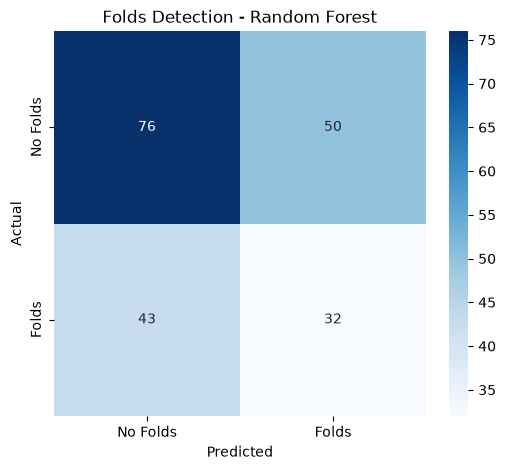

In [61]:
cm_folds = confusion_matrix(
    y_test,
    rf_folds_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_folds,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Folds", "Folds"],
    yticklabels=["No Folds", "Folds"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Folds Detection - Random Forest")

plt.show()

In [63]:
poly_df = df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Polymorphism_Pleomorphism"
    ]
].dropna().copy()

print("Polymorphism/Pleomorphism dataset size:", len(poly_df))
print("\nClasses:")
print(poly_df["Polymorphism_Pleomorphism"].value_counts())

Polymorphism/Pleomorphism dataset size: 1003

Classes:
Polymorphism_Pleomorphism
0    873
1    130
Name: count, dtype: int64


In [64]:
X = poly_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = poly_df["Polymorphism_Pleomorphism"]

In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
Polymorphism_Pleomorphism
0    698
1    104
Name: count, dtype: int64

Testing classes:
Polymorphism_Pleomorphism
0    175
1     26
Name: count, dtype: int64


In [66]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

poly_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

poly_logistic.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

poly_pred = poly_logistic.predict(X_test_scaled)

poly_prob = poly_logistic.predict_proba(
    X_test_scaled
)[:, 1]

print("Polymorphism/Pleomorphism Logistic Regression")
print("-----------------------------------------------")

print(f"Accuracy : {accuracy_score(y_test, poly_pred):.4f}")
print(f"Precision: {precision_score(y_test, poly_pred):.4f}")
print(f"Recall   : {recall_score(y_test, poly_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, poly_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, poly_prob):.4f}")

Polymorphism/Pleomorphism Logistic Regression
-----------------------------------------------
Accuracy : 0.9204
Precision: 0.6190
Recall   : 1.0000
F1 Score : 0.7647
ROC-AUC  : 0.9747


In [68]:
from sklearn.ensemble import RandomForestClassifier

rf_poly = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced"
)

rf_poly.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [69]:
rf_poly_pred = rf_poly.predict(X_test)

rf_poly_prob = rf_poly.predict_proba(
    X_test
)[:, 1]

In [70]:
rf_poly_accuracy = accuracy_score(y_test, rf_poly_pred)
rf_poly_precision = precision_score(y_test, rf_poly_pred)
rf_poly_recall = recall_score(y_test, rf_poly_pred)
rf_poly_f1 = f1_score(y_test, rf_poly_pred)
rf_poly_roc = roc_auc_score(y_test, rf_poly_prob)

print("Polymorphism/Pleomorphism Random Forest")
print("-----------------------------------------")
print(f"Accuracy : {rf_poly_accuracy:.4f}")
print(f"Precision: {rf_poly_precision:.4f}")
print(f"Recall   : {rf_poly_recall:.4f}")
print(f"F1 Score : {rf_poly_f1:.4f}")
print(f"ROC-AUC  : {rf_poly_roc:.4f}")

Polymorphism/Pleomorphism Random Forest
-----------------------------------------
Accuracy : 0.9552
Precision: 0.7576
Recall   : 0.9615
F1 Score : 0.8475
ROC-AUC  : 0.9685


In [71]:
feature_importance_poly = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_poly.feature_importances_
})

feature_importance_poly = feature_importance_poly.sort_values(
    "Importance",
    ascending=False
)

feature_importance_poly

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.891809
2,HEX_percent,0.058546
1,CV,0.049645


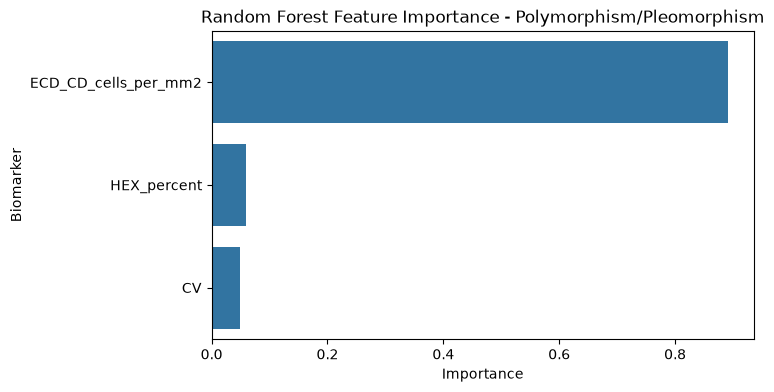

In [72]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=feature_importance_poly,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance - Polymorphism/Pleomorphism")
plt.xlabel("Importance")
plt.ylabel("Biomarker")

plt.show()

In [73]:
lowcell_df = df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent",
        "Low_Cell_Density"
    ]
].dropna().copy()

print("Low Cell Density dataset size:", len(lowcell_df))
print("\nClasses:")
print(lowcell_df["Low_Cell_Density"].value_counts())

Low Cell Density dataset size: 1003

Classes:
Low_Cell_Density
0    879
1    124
Name: count, dtype: int64


In [74]:
X = lowcell_df[
    [
        "ECD_CD_cells_per_mm2",
        "CV",
        "HEX_percent"
    ]
]

y = lowcell_df["Low_Cell_Density"]

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining classes:")
print(y_train.value_counts())

print("\nTesting classes:")
print(y_test.value_counts())

Training samples: 802
Testing samples: 201

Training classes:
Low_Cell_Density
0    703
1     99
Name: count, dtype: int64

Testing classes:
Low_Cell_Density
0    176
1     25
Name: count, dtype: int64


In [76]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lowcell_logistic = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

lowcell_logistic.fit(
    X_train_scaled,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to u

In [77]:
lowcell_pred = lowcell_logistic.predict(X_test_scaled)

lowcell_prob = lowcell_logistic.predict_proba(
    X_test_scaled
)[:, 1]

print("Low Cell Density Logistic Regression")
print("-------------------------------------")

print(f"Accuracy : {accuracy_score(y_test, lowcell_pred):.4f}")
print(f"Precision: {precision_score(y_test, lowcell_pred):.4f}")
print(f"Recall   : {recall_score(y_test, lowcell_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, lowcell_pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, lowcell_prob):.4f}")

Low Cell Density Logistic Regression
-------------------------------------
Accuracy : 0.9303
Precision: 0.6571
Recall   : 0.9200
F1 Score : 0.7667
ROC-AUC  : 0.9536


In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_lowcell = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_lowcell.fit(X_train, y_train)

rf_lowcell_pred = rf_lowcell.predict(X_test)

rf_lowcell_prob = rf_lowcell.predict_proba(
    X_test
)[:, 1]

In [79]:
rf_lowcell_accuracy = accuracy_score(y_test, rf_lowcell_pred)
rf_lowcell_precision = precision_score(y_test, rf_lowcell_pred)
rf_lowcell_recall = recall_score(y_test, rf_lowcell_pred)
rf_lowcell_f1 = f1_score(y_test, rf_lowcell_pred)
rf_lowcell_roc = roc_auc_score(y_test, rf_lowcell_prob)

print("Low Cell Density Random Forest")
print("--------------------------------")
print(f"Accuracy : {rf_lowcell_accuracy:.4f}")
print(f"Precision: {rf_lowcell_precision:.4f}")
print(f"Recall   : {rf_lowcell_recall:.4f}")
print(f"F1 Score : {rf_lowcell_f1:.4f}")
print(f"ROC-AUC  : {rf_lowcell_roc:.4f}")

Low Cell Density Random Forest
--------------------------------
Accuracy : 0.9403
Precision: 0.6970
Recall   : 0.9200
F1 Score : 0.7931
ROC-AUC  : 0.9661


In [80]:
feature_importance_lowcell = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_lowcell.feature_importances_
})

feature_importance_lowcell = feature_importance_lowcell.sort_values(
    "Importance",
    ascending=False
)

feature_importance_lowcell

,Feature,Importance
0,ECD_CD_cells_per_mm2,0.903551
1,CV,0.050036
2,HEX_percent,0.046413


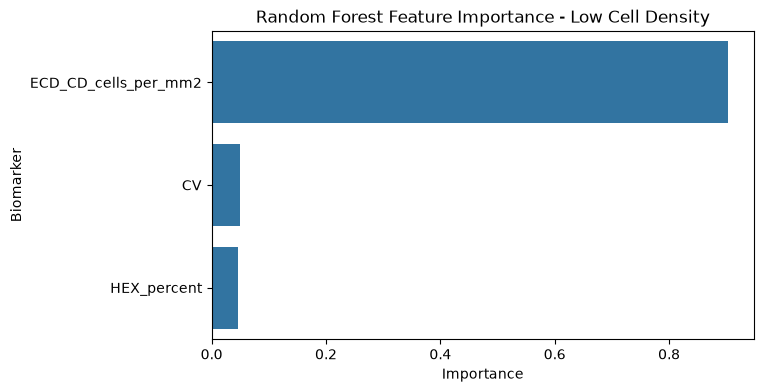

In [81]:
plt.figure(figsize=(7, 4))

sns.barplot(
    data=feature_importance_lowcell,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance - Low Cell Density")
plt.xlabel("Importance")
plt.ylabel("Biomarker")

plt.show()

In [82]:
biomarker_results = pd.DataFrame([
    ["FECD", "Logistic Regression", 0.9552, 0.7353, 1.0000, 0.8475, 0.9675],
    ["FECD", "Random Forest",       0.9552, 0.7353, 1.0000, 0.8475, 0.9834],

    ["Guttata", "Logistic Regression", 0.5224, 0.1042, 0.5000, 0.1724, 0.4942],
    ["Guttata", "Random Forest",       0.8209, 0.1364, 0.1500, 0.1429, 0.5729],

    ["Folds", "Logistic Regression", 0.5025, 0.3810, 0.5333, 0.4444, 0.5192],
    ["Folds", "Random Forest",       0.5373, 0.3902, 0.4267, 0.4076, 0.5146],

    ["Polymorphism/Pleomorphism", "Logistic Regression", 0.9204, 0.6190, 1.0000, 0.7647, 0.9747],
    ["Polymorphism/Pleomorphism", "Random Forest",       0.9552, 0.7576, 0.9615, 0.8475, 0.9685],

    ["Low Cell Density", "Logistic Regression", 0.9303, 0.6571, 0.9200, 0.7667, 0.9536],
    ["Low Cell Density", "Random Forest",       0.9403, 0.6970, 0.9200, 0.7931, 0.9661]
], columns=[
    "Disease", "Model", "Accuracy", "Precision",
    "Recall", "F1_Score", "ROC_AUC"
])

biomarker_results

,Disease,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,FECD,Logistic Regression,0.9552,0.7353,1.0000,0.8475,0.9675
1,FECD,Random Forest,0.9552,0.7353,1.0000,0.8475,0.9834
2,Guttata,Logistic Regression,0.5224,0.1042,0.5000,0.1724,0.4942
3,Guttata,Random Forest,0.8209,0.1364,0.1500,0.1429,0.5729
4,Folds,Logistic Regression,0.5025,0.3810,0.5333,0.4444,0.5192
5,Folds,Random Forest,0.5373,0.3902,0.4267,0.4076,0.5146
6,Polymorphism/Pleomorphism,Logistic Regression,0.9204,0.6190,1.0000,0.7647,0.9747
7,Polymorphism/Pleomorphism,Random Forest,0.9552,0.7576,0.9615,0.8475,0.9685
8,Low Cell Density,Logistic Regression,0.9303,0.6571,0.9200,0.7667,0.9536
9,Low Cell Density,Random Forest,0.9403,0.6970,0.9200,0.7931,0.9661
